In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.shape #In this dataset we have 2240 records and 22 features/columns

(2240, 22)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [6]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing

# 1. Handle Missing values

In [7]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [8]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

# Feature Engineering

In [9]:
# Age column
df["Age"] = 2026 - df["Year_Birth"]

In [10]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [11]:
#Customer Joining Data

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst = True)
reference_date =  df["Dt_Customer"].max()
df["Customer_tenure_days"] = (reference_date - df["Dt_Customer"]).dt.days
#customer tenure days is feature which tell us how many days passed for our customer to joined the platform

In [12]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_tenure_days'],
      dtype='object')

In [13]:
#Spending feature

df["Total_spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"] 


In [14]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_spending
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,8,10,4,7,0,1,69,663,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,1,1,2,5,0,0,72,113,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,1,8,2,10,4,0,0,61,312,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,2,0,4,6,0,0,42,139,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,5,3,6,5,0,0,45,161,422


In [15]:
#Children

df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [16]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_spending,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [17]:
#Education

df["Education"].value_counts()

df["Education"] = df["Education"].replace(
    {"Graduation":"Graduate","Basic":"Undergraduate","PhD":"Postgraduate","Master":"Postgraduate","2n Cycle":"Undergraduate"})

In [18]:
df["Education"].value_counts()


Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [19]:
#Marital Status
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [20]:
df["Living_With"] = df["Marital_Status"].replace(
    {"Married":"Partner","Together":"Partner","Single":"Alone","Divorced":"Alone","Widow":"Alone",
    "Absurd":"Alone","Alone":"Alone","YOLO":"Alone"})

In [21]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

# Drop columns

In [22]:
cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols = ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns = cols_to_drop)

In [23]:
df_cleaned.shape

(2240, 15)

In [24]:
df.shape

(2240, 27)

In [25]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# Outliers

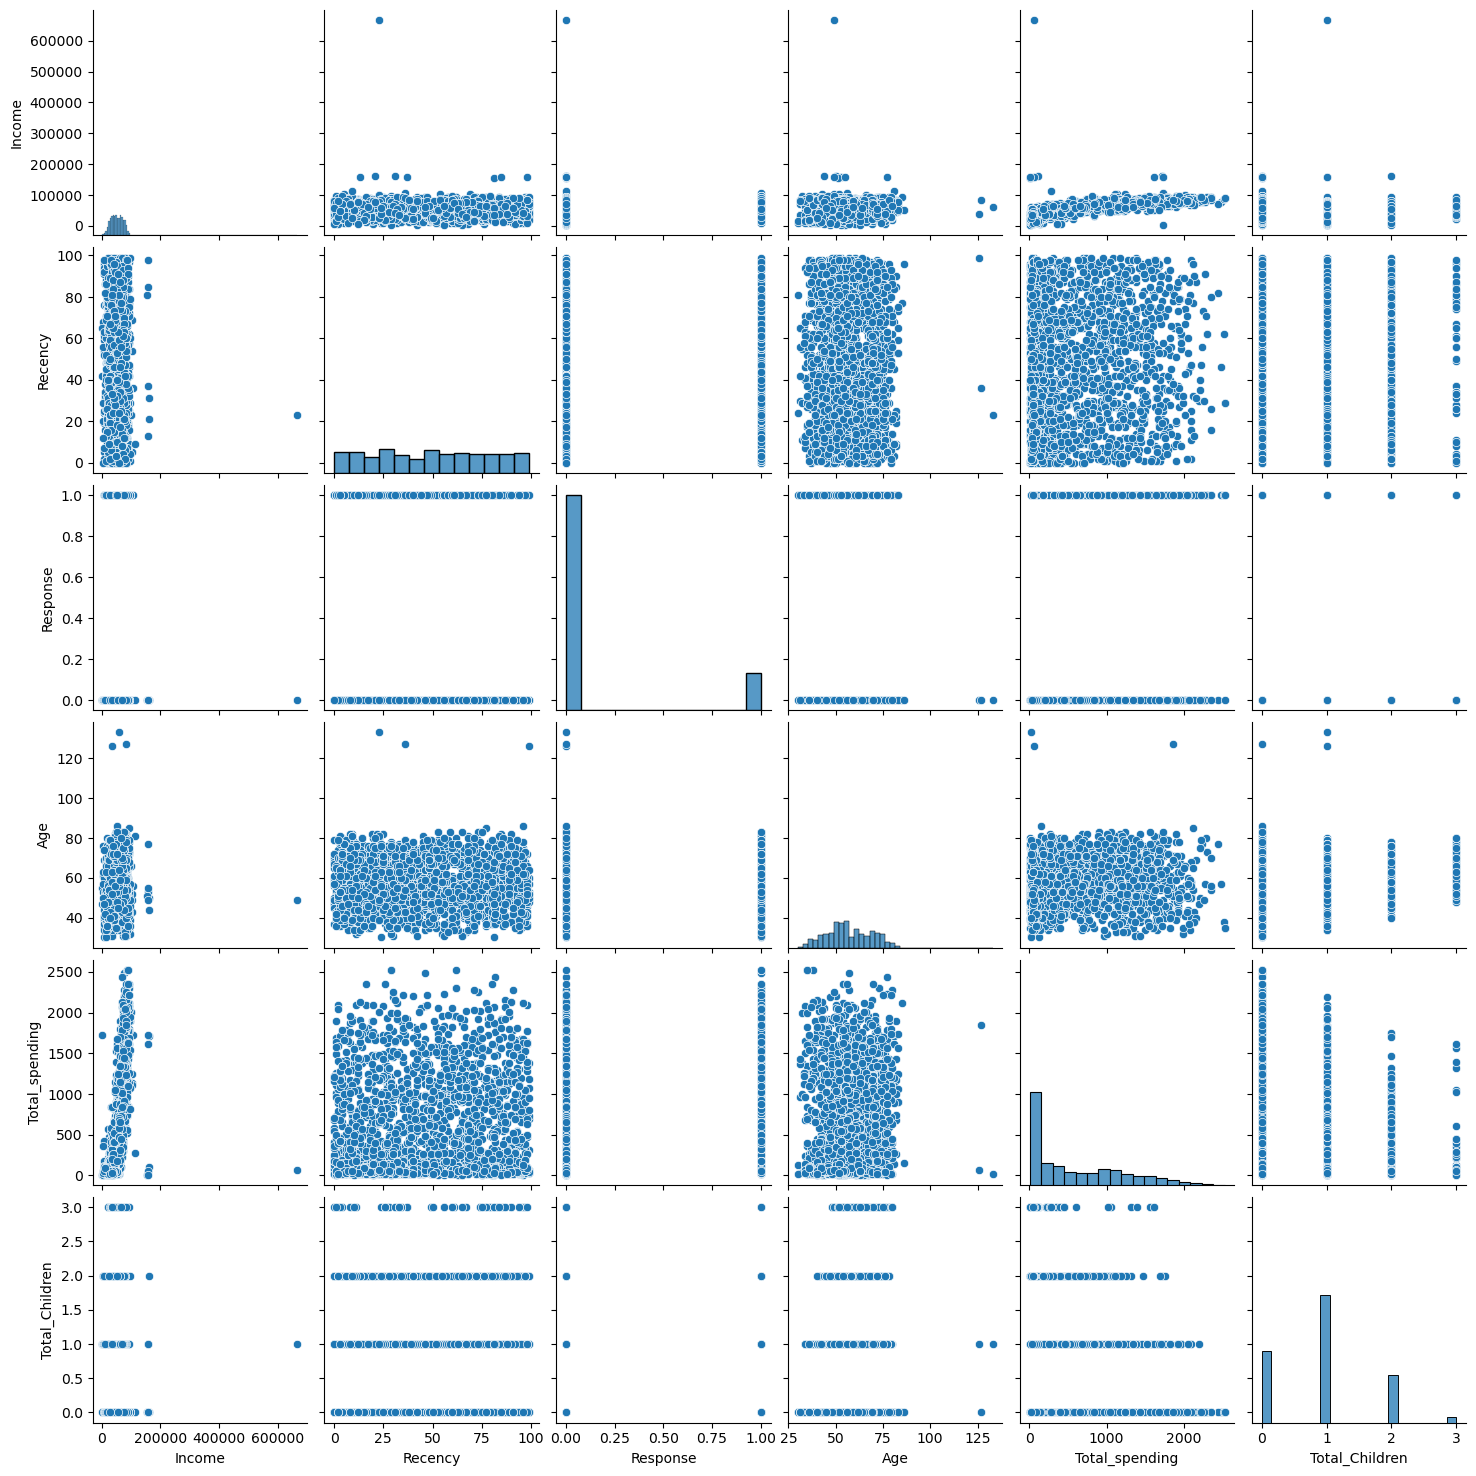

In [26]:
cols = ["Income","Recency","Response","Age","Total_spending","Total_Children"]

#relative plots of some features i.e pairplots  to find the outliers in data
sns.pairplot(df_cleaned[cols])

In [27]:
# Remove outliers

print("data size with outliers: ",len(df_cleaned))

df_cleaned = df_cleaned[df_cleaned["Age"] < 90 ]
df_cleaned = df_cleaned[df_cleaned["Income"] < 600000]

print("data size without outliers: ",len(df_cleaned))

data size with outliers:  2240
data size without outliers:  2236


# Heatmap

<Axes: >

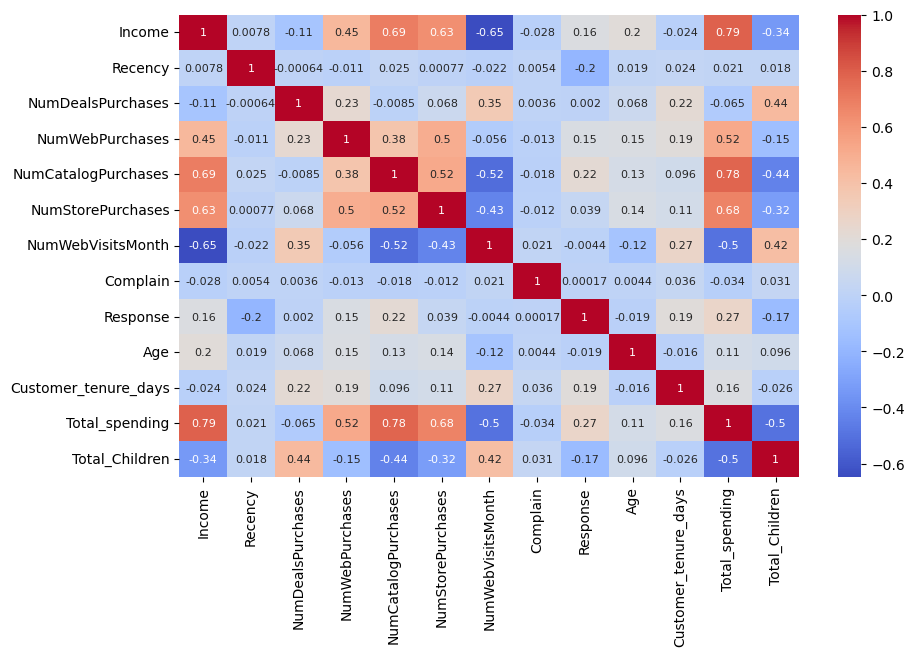

In [28]:
#Checking correlation between features using Heatmap

corr = df_cleaned.corr(numeric_only= True) # numeric_only means numerical features only

plt.figure(figsize = (10,6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws= {"size":8},
    cmap = "coolwarm"
)


# Encoding

In [29]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()
cat_cols = ["Education","Living_With"]
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

'''
In clustering, we usually do NOT use drop='first' in One-Hot Encoding because multicollinearity is not a concern.

The option drop='first' is mainly used in supervised linear models (such as Linear Regression and Logistic Regression) to avoid the Dummy Variable Trap (multicollinearity).

Clustering algorithms (such as K-Means, DBSCAN, Hierarchical Clustering, etc.) do not estimate coefficients like linear models, so multicollinearity does not affect them.

If we use drop='first' in clustering, we remove one category, which may result in losing useful information about the similarity or dissimilarity between data points. Therefore, we generally keep all one-hot encoded columns .
'''

"\nIn clustering, we usually do NOT use drop='first' in One-Hot Encoding because multicollinearity is not a concern.\n\nThe option drop='first' is mainly used in supervised linear models (such as Linear Regression and Logistic Regression) to avoid the Dummy Variable Trap (multicollinearity).\n\nClustering algorithms (such as K-Means, DBSCAN, Hierarchical Clustering, etc.) do not estimate coefficients like linear models, so multicollinearity does not affect them.\n\nIf we use drop='first' in clustering, we remove one category, which may result in losing useful information about the similarity or dissimilarity between data points. Therefore, we generally keep all one-hot encoded columns .\n"

In [30]:
enc_df = pd.DataFrame(enc_cols.toarray(),columns = ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)

In [31]:
enc_df.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [32]:
df_encoded = pd.concat([df_cleaned.drop(columns = cat_cols) ,enc_df],axis = 1)

In [33]:
df_encoded.shape

(2236, 18)

In [34]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


# Scaling

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [36]:
X = df_encoded

In [37]:
X_scaled = scaler.fit_transform(X)

In [38]:
X_scaled

array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]])

# Visualize

In [39]:
X_scaled.shape # We have 18 features to visualize and it is hard to visualize. So we will PCA for reducing features

(2236, 18)

In [40]:
from sklearn.decomposition import PCA

pca = PCA(n_components= 2)
X_pca = pca.fit_transform(X_scaled)

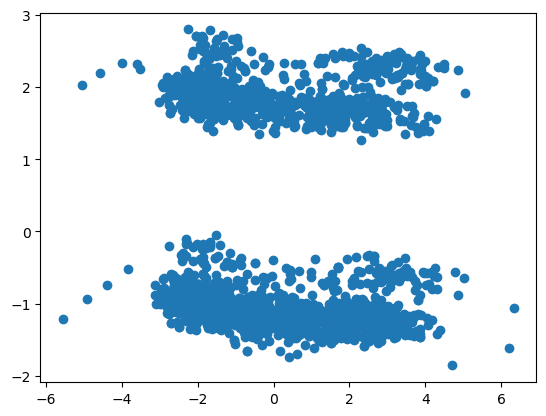

In [41]:
plt.scatter(X_pca[:,0],X_pca[:,1])

In [42]:
pca.explained_variance_ratio_ # In this 2d , our 2 PCs only 34 % varince which is not enough

array([0.23163158, 0.11385454])

In [43]:
from sklearn.decomposition import PCA

pca = PCA(n_components= 3)
X_pca = pca.fit_transform(X_scaled)

In [44]:
pca.explained_variance_ratio_ # Decomposing to 3 features is better then 2 features as more varince(spread of data) we are getting
# in this case

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3d Projection')

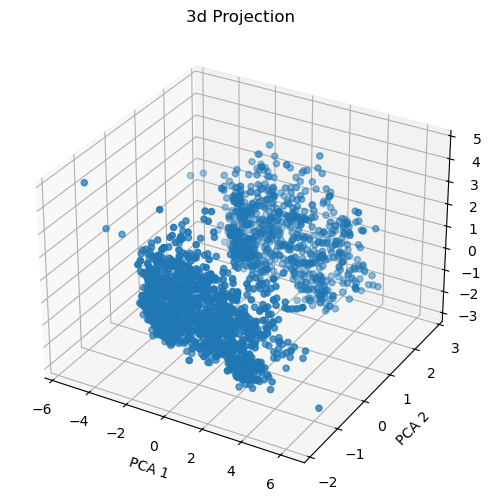

In [45]:
# 3d Visualize

fig = plt.figure(figsize = [10,6])

ax = fig.add_subplot(111,projection = "3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])

ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")
ax.set_title("3d Projection")

# Analyze K value
## 1. Elbow Method

In [47]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters= k,random_state = 42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [48]:
knee = KneeLocator(range(1,11),wcss,curve = "convex",direction = "decreasing")
Optimal_k = knee.elbow

Text(0, 0.5, 'WCSS values')

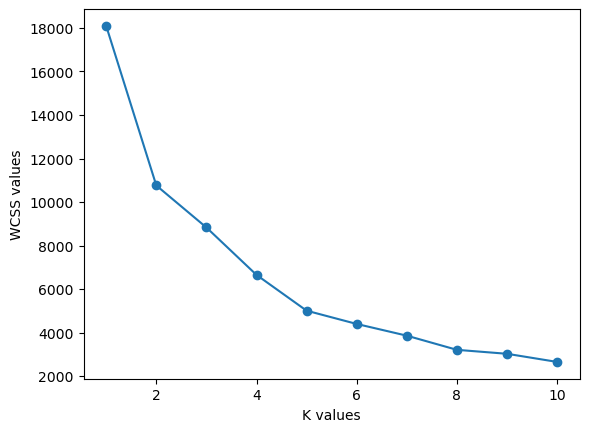

In [49]:
#Elbow method plot

plt.plot(range(1,11),wcss,marker = "o")
plt.xlabel("K values")
plt.ylabel("WCSS values")

In [50]:
print(f"Best K value: {Optimal_k}")

Best K value: 4


## 2. Silhoutte Score

Text(0, 0.5, 'Silhoutte score')

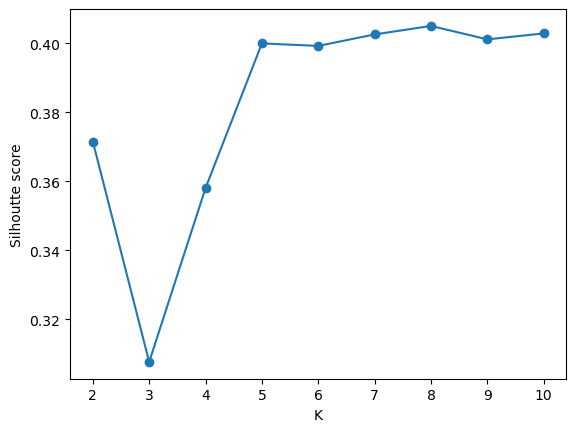

In [51]:
from sklearn.metrics import silhouette_score

scores = []
for k in range(2,11):
    kmeans = KMeans(n_clusters= k,random_state= 42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca,labels)
    scores.append(score)

#plot
plt.plot(range(2,11),scores,marker = "o")
plt.xlabel("K")
plt.ylabel("Silhoutte score")



Text(0, 0.5, 'score values')

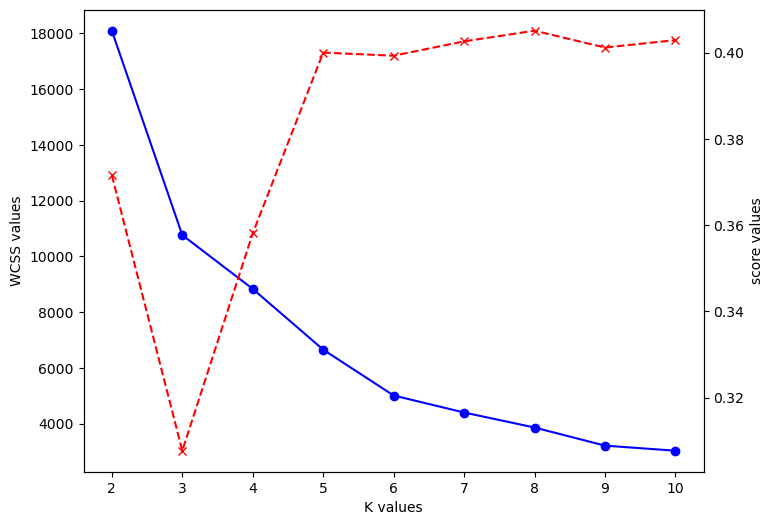

In [52]:
#Combined plot

k_range = range(2,11)
fig,ax1 = plt.subplots(figsize = (8,6))
ax1.plot(k_range,wcss[:len(k_range)],marker = "o",color ="blue")
ax1.set_xlabel("K values")
ax1.set_ylabel("WCSS values")

ax2 = ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker = "x",color ="red",linestyle = "--")
ax2.set_ylabel("score values")

#By this combined plot of elbow and silhoutte score we can see that they are intersecting near 4 , so always choose/ find the optimal
#k value and in this case the optimal k value is 4

# Clustering

In [53]:
kmeans = KMeans(n_clusters = 4,random_state = 42)
labels_kmeans = kmeans.fit_predict(X_pca)

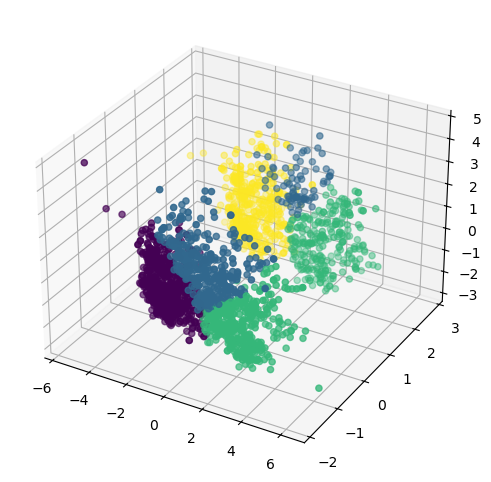

In [54]:
#Kmeans clusters in 3d plot
fig = plt.figure(figsize = [10,6])

ax = fig.add_subplot(111,projection = "3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c = labels_kmeans)

In [55]:
#Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

agg_clf = AgglomerativeClustering(n_clusters= 4,linkage = "ward")
labels_agg = agg_clf.fit_predict(X_pca)


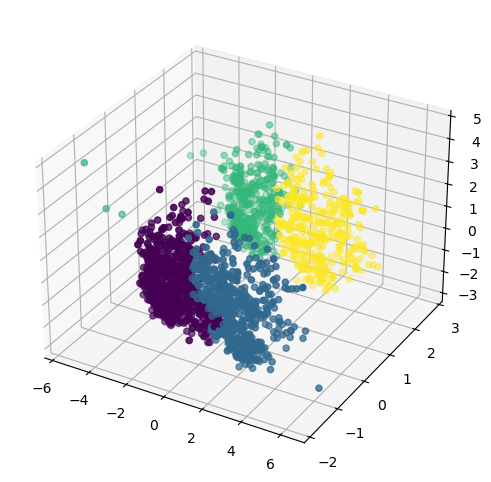

In [56]:
#Agglomerative clustering  clusters in 3d plot
fig = plt.figure(figsize = [10,6])

ax = fig.add_subplot(111,projection = "3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c = labels_agg)

# Characterisation of clusters

In [68]:
X["clusters"] = labels_agg

In [69]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


In [70]:
X["clusters"].value_counts()

clusters
0    905
1    534
2    444
3    353
Name: count, dtype: int64

<Axes: xlabel='clusters', ylabel='count'>

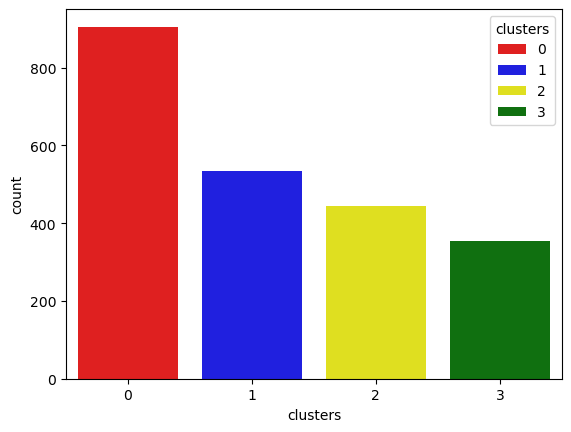

In [71]:
pal = ["red","blue","yellow","green"]
sns.countplot(x = X["clusters"],palette = pal,hue = X["clusters"])

<Axes: xlabel='Total_spending', ylabel='Income'>

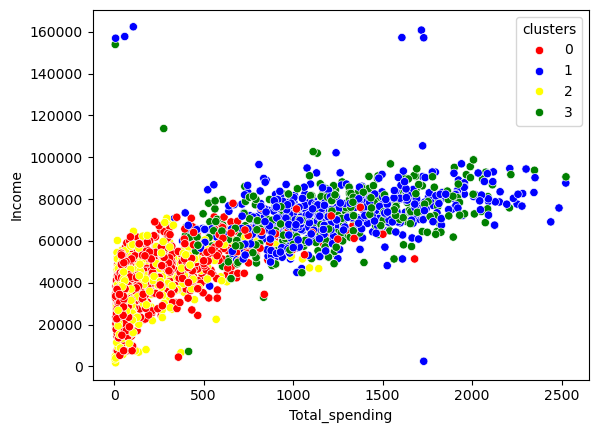

In [72]:
#As in heatmap , we seen that Income and spending had the highest correaltion value, so now first we will check them

#Income and spending patterns
sns.scatterplot(x = X["Total_spending"],y = X["Income"],hue = X["clusters"],palette = pal)

In [ ]:
#Observations:

'''
cluster 0 : Red
Low/Moderate Income
Low/Moderate spending

cluster 1 : Blue
High Income
High Spending

cluster 2: Yellow
Low Income
Low  Spending

cluster 3: Green
Moderate-low Income
High Spending



By this we can spendings of cluster 1 and cluster 3 is higher and generally their incomes are also higher.
But if we talk about clusters 0 and 2 , their spndings and incomes both are lower as compared to cluster 1 and 3

'''

# Cluster Summary

In [74]:
cluster_summary = X.groupby("clusters").mean()
print(cluster_summary)

# 1.Here by Income and spending patterns we can see that cluster 1 and cluster 3 are high spending and high Income. So cart comapny 
#they are the premium customer and cluster 0 and cluster 2 are low spending and low income so they are price-sensitive customers for 
#the cart company

#2. In this summary we can see that cluster 0 and 2 have more children and they are low spenders and clusters 1 and 3 have less
#children and they are high spenders

#3. In this summary , we can see that clusters 1 and 3 has slightly higher ages compared to clusters 0 and 2

# 4. In this summary, we can see that cluster 3 has best response, clusters 1 and 2 has average responses and cluster 0 has 
#poor response

# 5. In this summary, we can see that clusters 0  and 1  living with partner and clusters 2 and 3 are living alone

# 6. In this summary we can see that clusters 0 and 2 has high numberofwebvists and  clusters 1 and 3 has low numberofwebvists.

#7.  In this summary we can see that clusters 1 and 3 has high web ,store and high catlog purchases and clusters 0  has low web, store
# purchases and  cluster 2 has very low  web, store and catlog purchases

#Now seeing this patterns , we can give names to this clusters as for cluster 0 it will family shoppers , for this category we can 
give discounts and coupons and cluster 1 has average response but their purchases are quite high  so to them we will offer loyalty
programs as more you buy more connection u get with brand its loyalty. Cluster 2 is a digital broswsers as this alone parents 
with their childerns their repsonse is good but their purchases on store,catlog and web are low so we can target this customers
for sales in the sense if there are heavy discounts or heavy coupon amounts . Cluster 3 is a golden cluster as this cluster has 
best ROI in terms of Income , spending and response they have as they are more engaged with the smartcart  and this cluster customers
are alone  with fewer children so we can call this cluster as High value singles . To this High value singles cart company can offer
premium services as they are single people and high income earners. Also to  High value singles customers we can offer the personalized
services

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        Age  Customer_tenure_days  Total_spending  \
clu